In [1]:
import gzip
import shutil

with gzip.open('SRR494102.fastq.gz', 'rb') as f_in:
    with open('SRR494102.fastq', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print("¡Archivo descomprimido correctamente!")

¡Archivo descomprimido correctamente!


In [2]:
pip install biopython

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   -------------------------- ------------- 1.8/2.8 MB 13.9 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 13.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
from Bio import SeqIO
fq_dict = SeqIO.index("SRR494102.fastq", "fastq")

In [6]:
len(fq_dict)

27626583

In [7]:
list(fq_dict.keys())[:4]

['SRR494102.1', 'SRR494102.2', 'SRR494102.3', 'SRR494102.4']

In [9]:
fq_dict["SRR494102.374972"].seq

Seq('CCCAATCCAGAACCCAAACCACCAGAAGGCTCCTCC')

In [10]:
from Bio.Seq import Seq

# Ejemplo con una secuencia del FASTQ
secuencia_adn = fq_dict["SRR494102.20000"].seq
secuencia_arn = secuencia_adn.transcribe()  # Cambia T→U y maneja bases ambiguas

print(f"ADN: {secuencia_adn}")
print(f"ARN: {secuencia_arn}")

ADN: AGCAACCACCATGACCACCCCTTCACCAACCACCAC
ARN: AGCAACCACCAUGACCACCCCUUCACCAACCACCAC


In [14]:
aa_names = {
    'A': 'Alanina',
    'R': 'Arginina',
    'N': 'Asparagina',
    'D': 'Ácido aspártico',
    'C': 'Cisteína',
    'E': 'Ácido glutámico',
    'Q': 'Glutamina',
    'G': 'Glicina',
    'H': 'Histidina',
    'I': 'Isoleucina',
    'L': 'Leucina',
    'K': 'Lisina',
    'M': 'Metionina',
    'F': 'Fenilalanina',
    'P': 'Prolina',
    'S': 'Serina',
    'T': 'Treonina',
    'W': 'Triptófano',
    'Y': 'Tirosina',
    'V': 'Valina',
    '*': 'Stop'  # Codón de parada
}

In [15]:
from Bio.Seq import Seq

# Ejemplo con una secuencia
secuencia_adn = Seq("AGCAACCACCATGACCACCCCTTCACCAACCACCAC")  # ADN de ejemplo
proteina = secuencia_adn.translate()  # "MVT*"

# Obtener nombres de los aminoácidos
nombres_aa = [aa_names[aa] for aa in proteina]

print("Secuencia de proteína:", proteina)
print("Nombres de aminoácidos:", ", ".join(nombres_aa))

Secuencia de proteína: SNHHDHPFTNHH
Nombres de aminoácidos: Serina, Asparagina, Histidina, Histidina, Ácido aspártico, Histidina, Prolina, Fenilalanina, Treonina, Asparagina, Histidina, Histidina


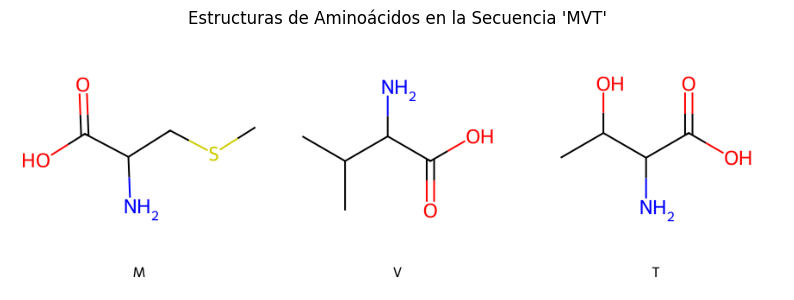

In [17]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore") 

# Diccionario de SMILES CORREGIDOS para aminoácidos (formato estándar)
aa_smiles = {
    'M': 'CSCC(C(=O)O)N',  # Metionina (M) - Corregido
    'V': 'CC(C)C(C(=O)O)N',  # Valina (V) - Corregido
    'T': 'CC(O)C(C(=O)O)N',  # Treonina (T) - Corregido
}

# Secuencia de ejemplo: "MVT"
secuencia_proteina = "MVT"
mols = []
legends = []

for aa in secuencia_proteina:
    if aa in aa_smiles:
        mol = Chem.MolFromSmiles(aa_smiles[aa])
        if mol:
            AllChem.Compute2DCoords(mol)  # Asegura coordenadas 2D
            mols.append(mol)
            legends.append(f"{aa}")
# Dibujar las estructuras
if mols:
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=len(mols),  # Una fila con todos los aminoácidos
        subImgSize=(300, 300),
        legends=legends,
        returnPNG=False
    )
    
    # Mostrar con matplotlib
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Estructuras de Aminoácidos en la Secuencia 'MVT'")
    plt.show()
else:
    print("No se pudieron generar las estructuras. Revisa los SMILES.")
